In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Load the machine learning result files

all_results = pd.read_csv("../csv/all_models_85_kinases.csv")

best_results = pd.read_csv("../csv/best_model_per_kinase.csv")

In [23]:
# Check the dimensions of both datasets

print("All model results shape:", all_results.shape)
print("Best model results shape:",best_results.shape)

All model results shape: (672, 6)
Best model results shape: (84, 6)


In [24]:
# Display the first five rows of both datasets

print("First five rows of all model results:")
display(all_results.head())

print("First five rows of best model results:")
display(best_results.head())

First five rows of all model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,RandomForest,-0.457206,0.321889,-0.085695,1.963618
1,O00418,XGBoost,-1.711004,1.304069,-0.365468,2.469622
2,O00418,PLS,-0.373195,0.323411,0.099489,1.628690
3,O00418,SVR,-0.395335,0.428539,0.119233,1.592978
4,O00418,Lasso,-0.197124,0.162209,0.051979,1.714617


First five rows of best model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,MLP,-0.996252,1.086327,0.178063,1.486578
1,O14578,Lasso,0.208584,0.191124,0.297690,0.371181
2,O15075,Lasso,-0.051415,0.055017,-0.042251,0.222621
3,O43318,SVR,-0.748041,0.538223,0.101737,0.585815
4,O43353,MLP,-0.545986,0.859548,0.319197,0.440717


In [25]:
# Get kinase information from the Kinepik API

import requests

url = "https://kinepik.org/api/0/kinases/all"

response = requests.get(url)

kinase_info = pd.DataFrame(response.json())

# Create a clean mapping between UniProt ID and gene name
kinase_gene_mapping = pd.DataFrame({
    "Kinase": kinase_info["UniprotID"],
    "GeneName": kinase_info["GeneInfo"].apply(lambda x: x["MappedGene"])
})

# Display the first five rows
display(kinase_gene_mapping.head())

,Kinase,GeneName
0,P06239,LCK
1,P12931,SRC
2,P06241,FYN
3,P00519,ABL1
4,P24941,CDK2


In [26]:
all_results_with_genes = all_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

print("All results shape:", all_results_with_genes.shape)

print(
    "Missing gene names:",
    all_results_with_genes["GeneName"].isna().sum()
)

All results shape: (672, 7)
Missing gene names: 0


In [27]:
# Add gene names to best results

best_results_with_genes = best_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

# Arrange GeneName immediately after Kinase

best_results_with_genes = best_results_with_genes[
    [
        "Kinase",
        "GeneName",
        "Model",
        "CV Mean R²",
        "CV Std R²",
        "Test R²",
        "Test MSE"
    ]
]

# Sort best results from highest to lowest Test R²

best_results_sorted = best_results_with_genes.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

display(best_results_sorted)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.967479,0.018931,0.983224,0.008478
1,Q96QT4,TRPM7,ElasticNet,0.789021,0.123438,0.946605,0.038335
2,Q9H0K1,SIK2,RandomForest,0.239974,0.220028,0.779219,0.323693
3,Q15139,PRKD1,SVR,0.209475,0.678899,0.699540,0.597442
4,Q8TD19,NEK9,SVR,0.273477,0.395104,0.677487,0.945521
...,...,...,...,...,...,...,...
79,Q13555,CAMK2G,Lasso,0.039187,0.178838,-0.341629,0.424854
80,O75676,RPS6KA4,SVR,-0.820522,1.164729,-0.379347,0.499142
81,P15056,BRAF,RandomForest,-2.132140,3.908434,-0.380139,3.059743
82,Q13263,TRIM28,ElasticNet,-0.144407,0.678721,-0.463672,0.088259


In [28]:
# Display the top 10 best-performing results

top_10 = best_results_sorted.head(10)

display(top_10)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.967479,0.018931,0.983224,0.008478
1,Q96QT4,TRPM7,ElasticNet,0.789021,0.123438,0.946605,0.038335
2,Q9H0K1,SIK2,RandomForest,0.239974,0.220028,0.779219,0.323693
3,Q15139,PRKD1,SVR,0.209475,0.678899,0.699540,0.597442
4,Q8TD19,NEK9,SVR,0.273477,0.395104,0.677487,0.945521
5,O96013,PAK4,MLP,0.414766,0.145645,0.662051,0.377802
6,Q15418,RPS6KA1,GradientBoosting,-0.664686,1.069829,0.614391,0.392893
7,Q96SB4,SRPK1,MLP,0.465932,0.213828,0.606641,0.806074
8,Q9Y2K2,SIK3,RandomForest,-0.060364,0.632793,0.582937,0.351974
9,Q06187,BTK,GradientBoosting,-0.027645,0.306786,0.574703,0.682298


In [29]:
# Identify the best and worst performing kinase-model combinations

best_performer = best_results_sorted.iloc[0]
worst_performer = best_results_sorted.iloc[-1]

print("BEST PERFORMING KINASE-MODEL COMBINATION")
print(best_performer)

print("\nWORST PERFORMING KINASE-MODEL COMBINATION")
print(worst_performer)

BEST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q9UKE5
GeneName          TNIK
Model              SVR
CV Mean R²    0.967479
CV Std R²     0.018931
Test R²       0.983224
Test MSE      0.008478
Name: 0, dtype: object

WORST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q8IVT5
GeneName          KSR1
Model              SVR
CV Mean R²   -0.623962
CV Std R²     0.489241
Test R²      -0.747901
Test MSE      3.440356
Name: 83, dtype: object


In [30]:
# Display the top 10 best and worst-performing kinase-model combinations

top_10_best = best_results_sorted.head(10)

top_10_worst = best_results_sorted.tail(10).sort_values(
    by="Test R²",
    ascending=True
).reset_index(drop=True)

print("TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_best)

print("TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_worst)

TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,SVR,0.967479,0.018931,0.983224,0.008478
1,Q96QT4,TRPM7,ElasticNet,0.789021,0.123438,0.946605,0.038335
2,Q9H0K1,SIK2,RandomForest,0.239974,0.220028,0.779219,0.323693
3,Q15139,PRKD1,SVR,0.209475,0.678899,0.699540,0.597442
4,Q8TD19,NEK9,SVR,0.273477,0.395104,0.677487,0.945521
5,O96013,PAK4,MLP,0.414766,0.145645,0.662051,0.377802
6,Q15418,RPS6KA1,GradientBoosting,-0.664686,1.069829,0.614391,0.392893
7,Q96SB4,SRPK1,MLP,0.465932,0.213828,0.606641,0.806074
8,Q9Y2K2,SIK3,RandomForest,-0.060364,0.632793,0.582937,0.351974
9,Q06187,BTK,GradientBoosting,-0.027645,0.306786,0.574703,0.682298


TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q8IVT5,KSR1,SVR,-0.623962,0.489241,-0.747901,3.440356
1,Q13263,TRIM28,ElasticNet,-0.144407,0.678721,-0.463672,0.088259
2,P15056,BRAF,RandomForest,-2.132140,3.908434,-0.380139,3.059743
3,O75676,RPS6KA4,SVR,-0.820522,1.164729,-0.379347,0.499142
4,Q13555,CAMK2G,Lasso,0.039187,0.178838,-0.341629,0.424854
5,Q9NSY1,BMP2K,Lasso,-0.007896,0.105950,-0.215087,0.288008
6,P42345,MTOR,SVR,-0.527455,0.497734,-0.188101,3.032692
7,Q99759,MAP3K3,MLP,-0.289754,0.267488,-0.168298,2.527428
8,Q13233,MAP3K1,SVR,-0.532469,0.360871,-0.145169,1.165715
9,Q00536,CDK16,MLP,-0.854347,1.680664,-0.118125,1.712595


In [31]:
#Saving all the important final dataset 

# save all model results with gene names

all_results_with_genes.to_csv(
    "all_results_with_genes.csv",
    index=False 
)

print("Saved: all_results_with_genes.csv")

Saved: all_results_with_genes.csv


In [32]:
#Save best results for eacch kinase

best_results.to_csv(
    "best_results_with_genes.csv",
    index=False 
)

print("Saved: best_results_with_genes.csv")

Saved: best_results_with_genes.csv


In [33]:
#save sorted best results

best_results_sorted.to_csv(
    "best_results_sorted.csv",
    index=False 
)

print("Saved: best_results_sorted.csv")

Saved: best_results_sorted.csv


In [34]:
#Save top 10 best

top_10_best.to_csv(
    "top_10_best_kinases.csv",
    index=False
)

print("Saved: top_10_best_kinases.csv")

Saved: top_10_best_kinases.csv


In [35]:
# save top 10 worst

top_10_worst.to_csv(
    "top_10_worst_kinases.csv",
    index=False 
)

print("Saved: top_10_worst_kinases.csv")

Saved: top_10_worst_kinases.csv


In [36]:
#Load the predictions CSV

predictions = pd.read_csv("../csv/all_predictions.csv")
predictions

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,RandomForest,1.052219,-0.323114
1,O00418,EEF2K,RandomForest,-1.198411,0.561689
2,O00418,EEF2K,RandomForest,-5.056908,-0.149069
3,O00418,EEF2K,RandomForest,0.538401,0.132327
4,O00418,EEF2K,RandomForest,-0.508058,0.089789
...,...,...,...,...,...
12763,Q9Y3S1,WNK2,MLP,-1.931640,-0.120961
12764,Q9Y3S1,WNK2,MLP,-1.070606,-0.306605
12765,Q9Y3S1,WNK2,MLP,0.435586,-0.302278
12766,Q9Y3S1,WNK2,MLP,0.702182,-0.301327


In [37]:
#load the best model table
best_models = pd.read_csv("best_results_with_genes.csv")

best_models.head()

,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,MLP,-0.996252,1.086327,0.178063,1.486578
1,O14578,Lasso,0.208584,0.191124,0.297690,0.371181
2,O15075,Lasso,-0.051415,0.055017,-0.042251,0.222621
3,O43318,SVR,-0.748041,0.538223,0.101737,0.585815
4,O43353,MLP,-0.545986,0.859548,0.319197,0.440717


In [38]:
# keep only predictions from the best model 

best_predictions = predictions.merge(
    best_models[["Kinase", "Model"]],
    on=["Kinase", "Model"],
    how="inner"
)

best_predictions.head()

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,MLP,1.052219,-0.029437
1,O00418,EEF2K,MLP,-1.198411,0.089320
2,O00418,EEF2K,MLP,-5.056908,-0.739762
3,O00418,EEF2K,MLP,0.538401,0.369861
4,O00418,EEF2K,MLP,-0.508058,0.061811


In [39]:
best_predictions.to_csv(
    "best_predictions.csv",
    index=False 
)

print("Saved best_predictions.csv")

Saved best_predictions.csv


In [40]:
print(best_predictions.shape)
best_predictions.head()

(1596, 5)


,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,MLP,1.052219,-0.029437
1,O00418,EEF2K,MLP,-1.198411,0.089320
2,O00418,EEF2K,MLP,-5.056908,-0.739762
3,O00418,EEF2K,MLP,0.538401,0.369861
4,O00418,EEF2K,MLP,-0.508058,0.061811


In [41]:
def plot_actual_vs_predicted(predictions_df, kinase_list, title_prefix):
    """
    Plot Actual vs Predicted scatter plots for multiple kinases.

    Parameters
    ----------
    predictions_df : dataframe
        best_predictions dataframe

    kinase_list : list
        list of kinase IDs

    title_prefix : str
        title shown above plots
    """

    n = len(kinase_list)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=5,
        figsize=(22,9)
    )

    axes = axes.flatten()

    for ax, kinase in zip(axes, kinase_list):

        df = predictions_df[predictions_df["Kinase"] == kinase]

        gene = df["GeneName"].iloc[0]
        model = df["Model"].iloc[0]

        actual = df["Actual"]
        predicted = df["Predicted"]

        ax.scatter(actual, predicted, alpha=0.7)

        # identity line
        mn = min(actual.min(), predicted.min())
        mx = max(actual.max(), predicted.max())

        ax.plot(
            [mn, mx],
            [mn, mx],
            "r--",
            linewidth=1
        )

        ax.set_title(f"{gene} ({model})", fontsize=10)

        ax.set_xlabel("Actual")

        ax.set_ylabel("Predicted")

    plt.suptitle(
        title_prefix,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()



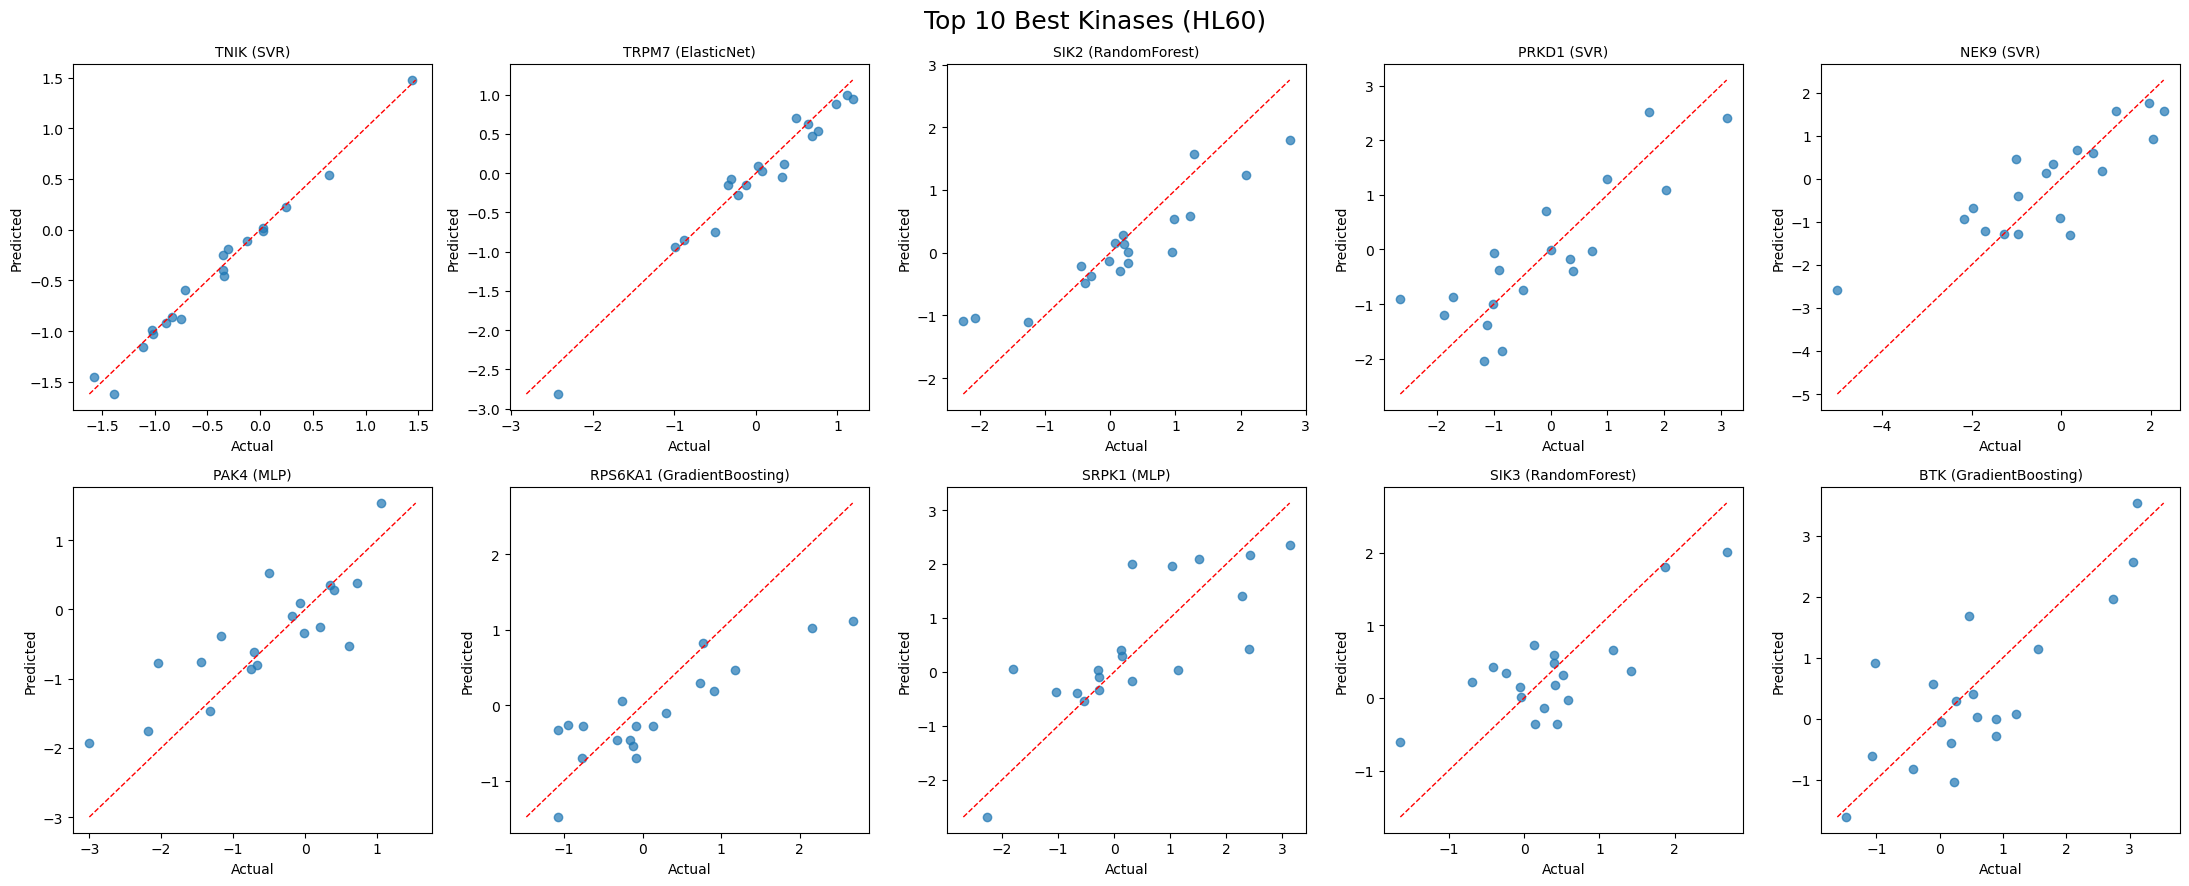

<Figure size 640x480 with 0 Axes>

In [42]:
#Generate toop 10 best

top10_best_ids = top_10_best["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_best_ids,
    "Top 10 Best Kinases (HL60)" 
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

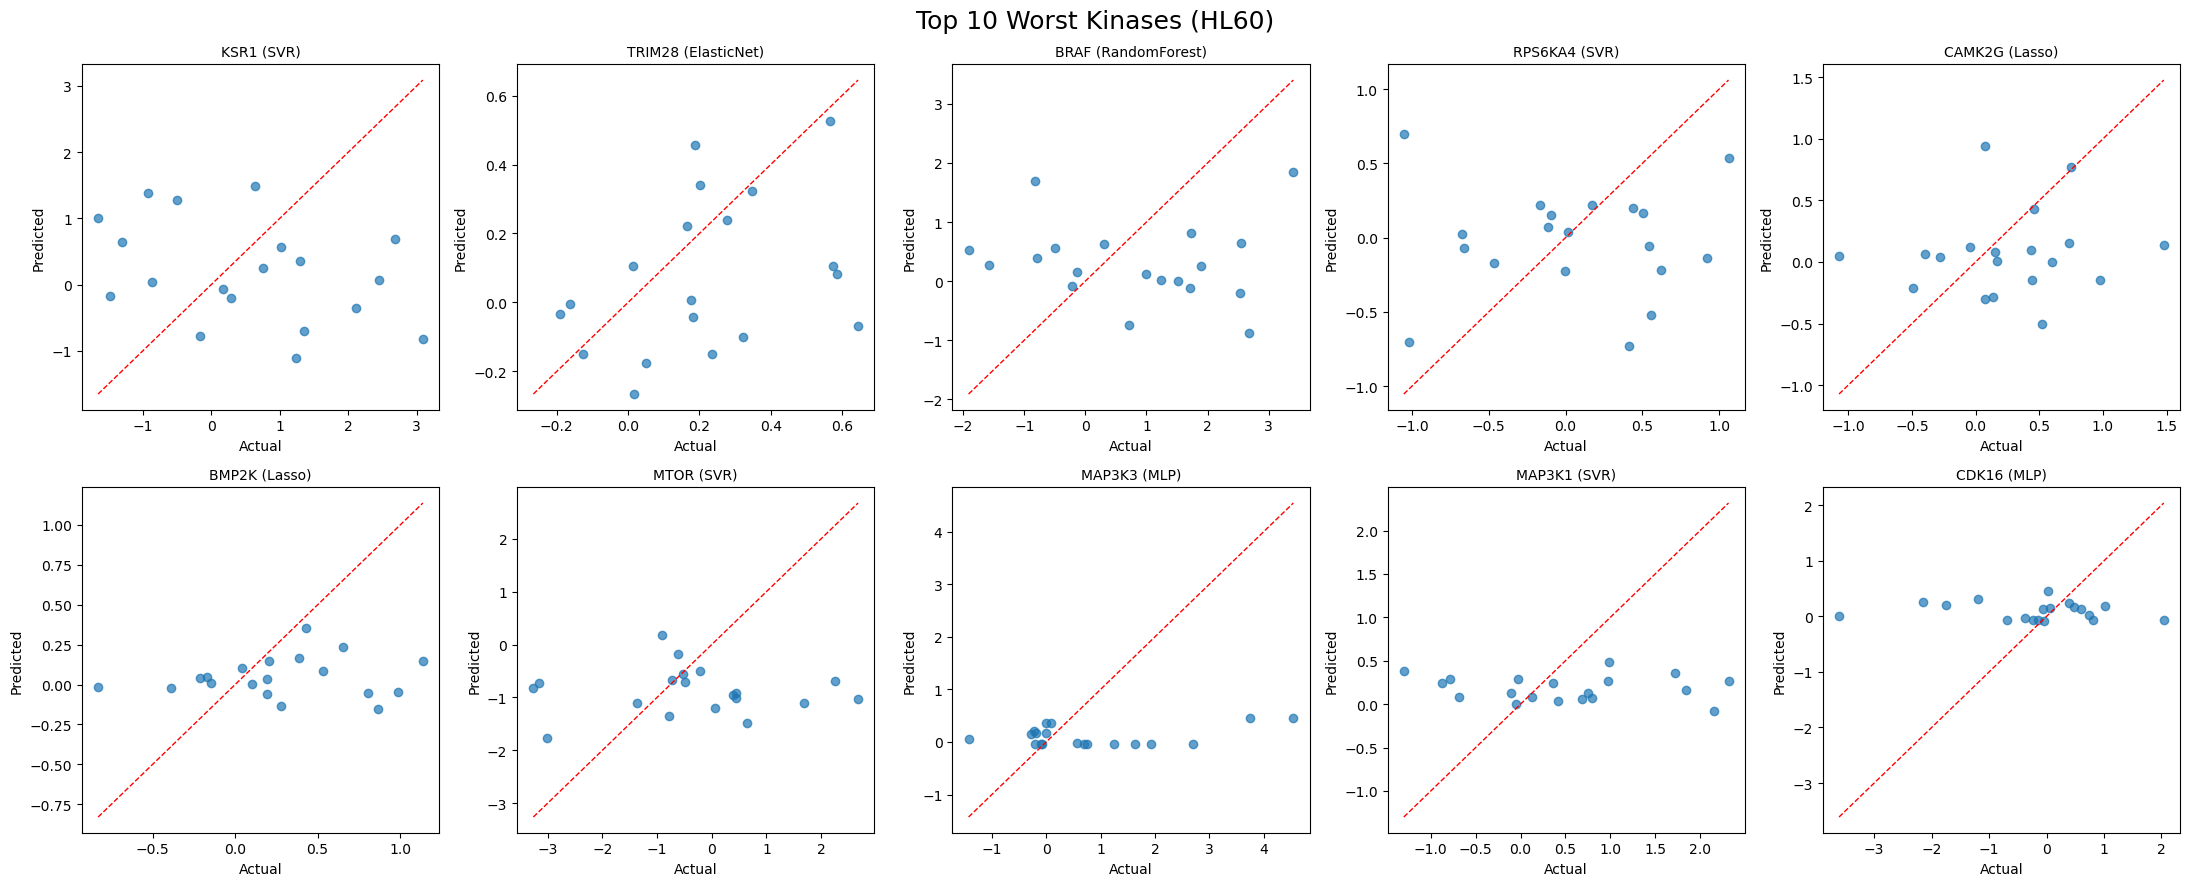

<Figure size 640x480 with 0 Axes>

In [43]:
top10_worst_ids = top_10_worst["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_worst_ids,
    "Top 10 Worst Kinases (HL60)"
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

In [45]:
#Load the phosphosite counts

phosphosite_counts = pd.read_csv("../csv/phosphosite_counts.csv")

phosphosite_counts.head()

,UniprotID,GeneName,TotalPhosphosites,Phosphosites
0,P06239,LCK,6,"['LCK(Y394)', 'LCK(Y505)', 'LCK(Y192)', 'LCK(S..."
1,P12931,SRC,17,"['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y..."
2,P06241,FYN,13,"['FYN(Y39)', 'FYN(Y420)', 'FYN(Y28)', 'FYN(Y30..."
3,P00519,ABL1,37,"['ABL1(S446)', 'ABL1(S465)', 'ABL1(Y393)', 'AB..."
4,P24941,CDK2,9,"['CDK2(T160)', 'CDK2(Y168)', 'CDK2(S46)', 'CDK..."


In [46]:
# Merge phosphosite counts with best model table

best_models = best_models.merge(
    phosphosite_counts[["UniprotID", "GeneName", "TotalPhosphosites"]],
    left_on="Kinase",
    right_on="UniprotID",
    how="left"
)

# Remove UniProt columns
best_models.drop(columns=["Kinase", "UniprotID"], inplace=True)

# Put GeneName as the first column
cols = ["GeneName"] + [c for c in best_models.columns if c != "GeneName"]
best_models = best_models[cols]

best_models.head()

,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,TotalPhosphosites
0,EEF2K,MLP,-0.996252,1.086327,0.178063,1.486578,19
1,CIT,Lasso,0.208584,0.191124,0.297690,0.371181,6
2,DCLK1,Lasso,-0.051415,0.055017,-0.042251,0.222621,10
3,MAP3K7,SVR,-0.748041,0.538223,0.101737,0.585815,11
4,RIPK2,MLP,-0.545986,0.859548,0.319197,0.440717,10


In [47]:
best_models.columns

Index(['GeneName', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE',
       'TotalPhosphosites'],
      dtype='object')

In [48]:
print(best_models.columns.tolist())

['GeneName', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE', 'TotalPhosphosites']


In [49]:
# Keep only the columns needed
#When merged datarames earlier, pandas automatically created two identical phosphosite columns (_x and _y).
#for plotting R2 vs phosphosite count , i only need one phosphosite column.

best_models = (
    best_models[
        ["GeneName", "Model", "Test R²", "TotalPhosphosites"]
    ]
    .rename(columns={"TotalPhosphosites": "TotalPhosphosites"})
)

best_models.head()

,GeneName,Model,Test R²,TotalPhosphosites
0,EEF2K,MLP,0.178063,19
1,CIT,Lasso,0.297690,6
2,DCLK1,Lasso,-0.042251,10
3,MAP3K7,SVR,0.101737,11
4,RIPK2,MLP,0.319197,10


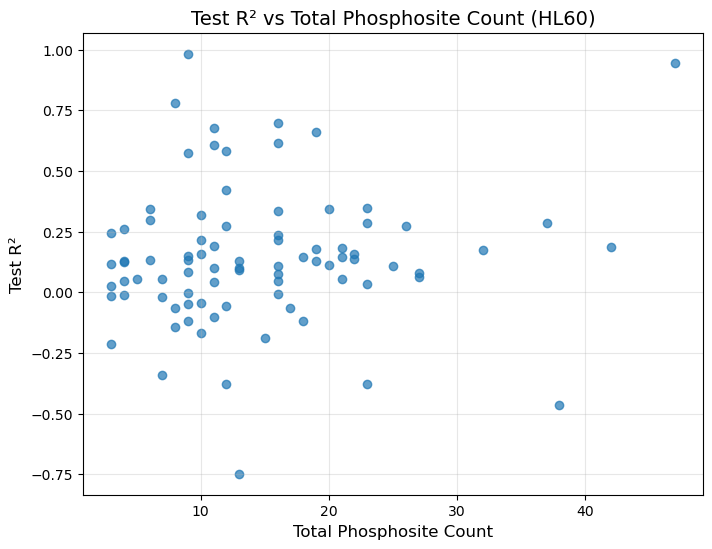

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_models["TotalPhosphosites"],
    best_models["Test R²"],
    alpha=0.7
)

plt.xlabel("Total Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("Test R² vs Total Phosphosite Count (HL60)", fontsize=14)

plt.grid(alpha=0.3)

plt.show()

In [51]:
#For R2 vs Target count

phosphosite_count = pd.read_csv("phosphosite_counts.csv")

phosphosite_count.head()

FileNotFoundError: [Errno 2] No such file or directory: 'phosphosite_counts.csv'

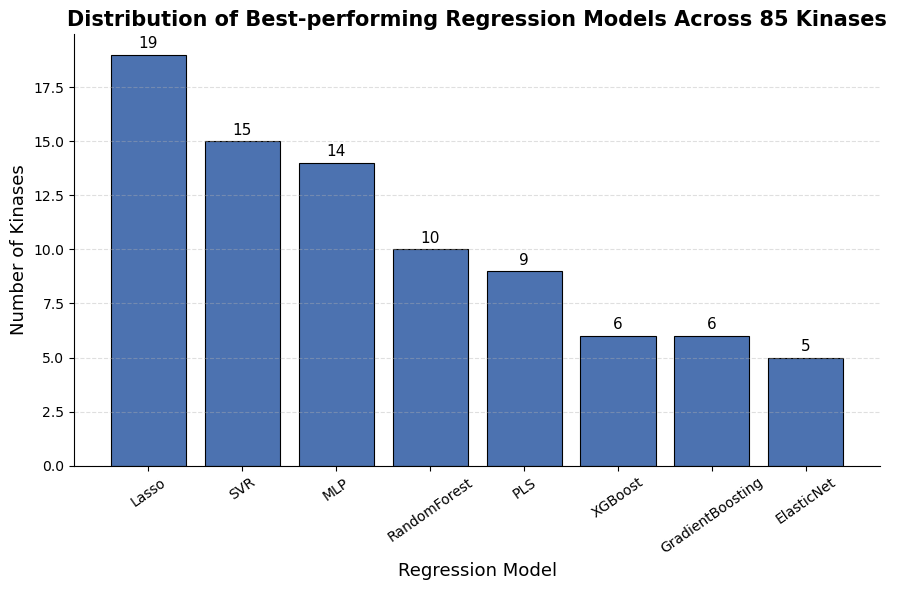

In [52]:


best_models = pd.read_csv("best_results_with_genes.csv")

model_counts = (
    best_models["Model"]
    .value_counts()
)

plt.figure(figsize=(9,6))

bars = plt.bar(
    model_counts.index,
    model_counts.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.xlabel("Regression Model", fontsize=13)
plt.ylabel("Number of Kinases", fontsize=13)

plt.title(
    "Distribution of Best-performing Regression Models Across 85 Kinases",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(
    "Figure_Model_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

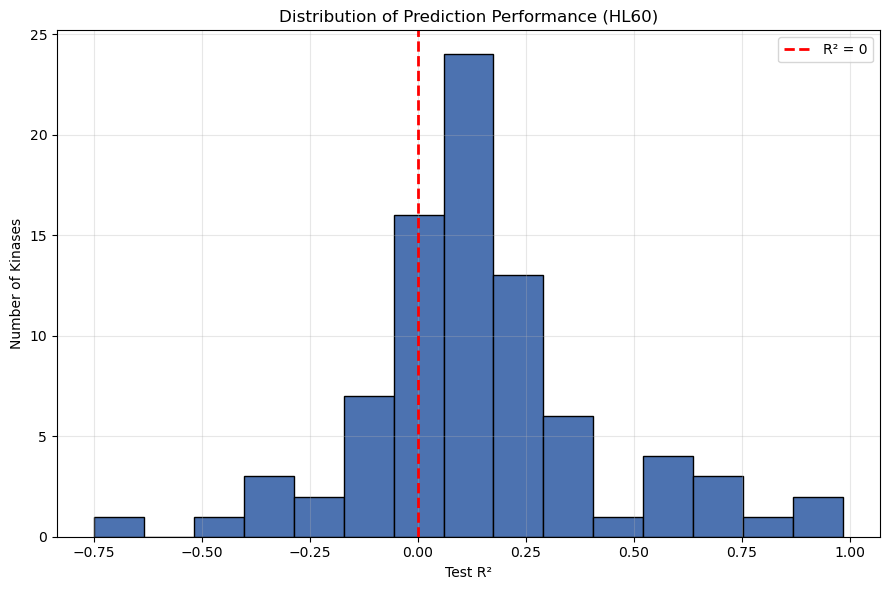

In [53]:
plt.figure(figsize=(9,6))

plt.hist(
    best_models["Test R²"],
    bins=15,
    color="#4C72B0",
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="R² = 0"
)

plt.xlabel("Test R²")
plt.ylabel("Number of Kinases")
plt.title("Distribution of Prediction Performance (HL60)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Histogram_Test_R2_HL60.png", dpi=300)
plt.show()

In [54]:
import pandas as pd

best_df = pd.read_csv("../csv/best_results_with_genes.csv")
target_df = pd.read_csv("../csv/target_phosphosite_counts.csv")

In [55]:
print(best_df.columns)
print(target_df.columns)

Index(['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE'], dtype='object')
Index(['UniprotID', 'GeneName', 'TargetPhosphositeCount',
       'TargetPhosphosites'],
      dtype='object')


In [56]:
print(best_df.columns.tolist())

['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE']


In [57]:
print(target_df.columns.tolist())

['UniprotID', 'GeneName', 'TargetPhosphositeCount', 'TargetPhosphosites']


In [58]:
merged_df = pd.merge(
    best_df,
    target_df,
    left_on="Kinase",
    right_on="UniprotID",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(84, 10)


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,UniprotID,GeneName,TargetPhosphositeCount,TargetPhosphosites
0,O00418,MLP,-0.996252,1.086327,0.178063,1.486578,O00418,EEF2K,7,"['EEF2(T59)', 'EEF2(T57)', 'EEF2(T54)', 'EEF2(..."
1,O14578,Lasso,0.208584,0.191124,0.297690,0.371181,O14578,CIT,3,"['MYL9(S20)', 'MYL9(T19)', 'SRF(T159)']"
2,O15075,Lasso,-0.051415,0.055017,-0.042251,0.222621,O15075,DCLK1,6,"['CAMKK1(S74)', 'CAMKK1(S458)', 'CAMKK1(S475)'..."
3,O43318,SVR,-0.748041,0.538223,0.101737,0.585815,O43318,MAP3K7,85,"['KSR1(S406)', 'RAB8A(T72)', 'PTPN3(S359)', 'H..."
4,O43353,MLP,-0.545986,0.859548,0.319197,0.440717,O43353,RIPK2,14,"['IRF5(S446)', 'IRF5(S435)', 'CRK(S41)', 'CRK(..."


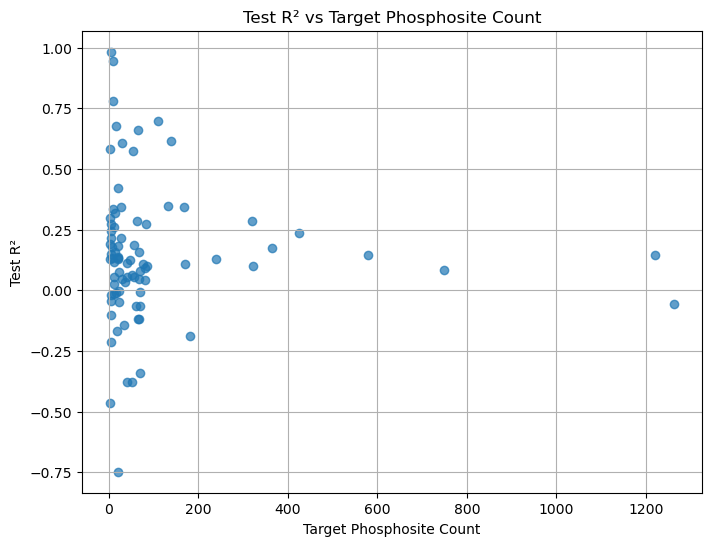

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7
)

plt.xlabel("Target Phosphosite Count")
plt.ylabel("Test R²")
plt.title("Test R² vs Target Phosphosite Count")

plt.grid(True)

plt.savefig(
    "R2_vs_Target_Phosphosite_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

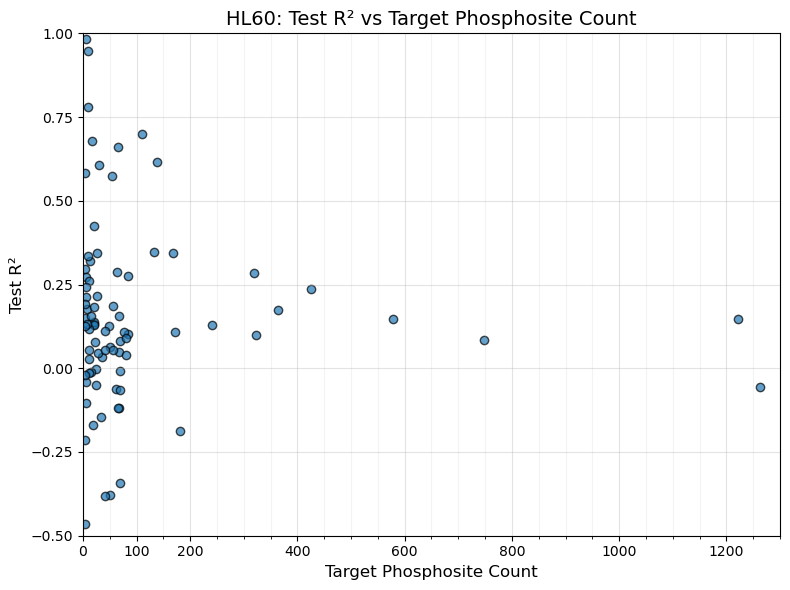

In [60]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

# Labels and title
plt.xlabel("Target Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("HL60: Test R² vs Target Phosphosite Count", fontsize=14)

# -------------------------------------------------
# SAME AXES FOR ALL CELL LINES
# -------------------------------------------------
plt.xlim(0, 1300)
plt.ylim(-0.5, 1.0)

# Major x-axis ticks
plt.xticks(
    [0, 100, 200, 400, 600, 800, 1000, 1200],
    fontsize=10
)

# Major y-axis ticks
plt.yticks(
    [-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0],
    fontsize=10
)

# Minor ticks every 50 phosphosites
ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(50))

# Gridlines
plt.grid(which="major", alpha=0.35)
plt.grid(which="minor", alpha=0.15)

# -------------------------------------------------

plt.tight_layout()

# Save figure
plt.savefig(
    "HL60_R2_vs_TargetPhosphositeCount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
import ast

best_df = pd.read_csv("../csv/best_model_per_kinase.csv")
sites_df = pd.read_csv("../csv/phosphosite_counts.csv")
targets_df = pd.read_csv("../csv/target_phosphosite_counts.csv")

In [63]:
#Step 2 Convert the phosphosite columns back to lists

sites_df["Phosphosites"] = sites_df["Phosphosites"].apply(ast.literal_eval)
targets_df["TargetPhosphosites"] = targets_df["TargetPhosphosites"].apply(ast.literal_eval)

In [64]:
# Step 3 - Merge the two phosphosite tables

merged_sites = pd.merge(
    sites_df,
    targets_df,
    on=["UniprotID","GeneName"],
    how="inner" 
)

print(merged_sites.shape)
merged_sites.head()

(504, 6)


,UniprotID,GeneName,TotalPhosphosites,Phosphosites,TargetPhosphositeCount,TargetPhosphosites
0,P06239,LCK,6,"[LCK(Y394), LCK(Y505), LCK(Y192), LCK(S42), LC...",204,"[SOCS3(Y204), SOCS3(Y221), ESR1(Y537), EZR(Y14..."
1,P12931,SRC,17,"[SRC(Y216), SRC(Y338), SRC(Y419), SRC(Y530), S...",947,"[TERT(Y707), PLSCR1(Y74), PLSCR1(Y69), PDPK1(Y..."
2,P06241,FYN,13,"[FYN(Y39), FYN(Y420), FYN(Y28), FYN(Y30), FYN(...",332,"[FYB1(Y651), FYB1(Y595), FYB1(Y697), FYB1(Y625..."
3,P00519,ABL1,37,"[ABL1(S446), ABL1(S465), ABL1(Y393), ABL1(Y226...",320,"[PLSCR1(Y74), PLSCR1(Y69), TP73(Y99), ANXA1(Y2..."
4,P24941,CDK2,9,"[CDK2(T160), CDK2(Y168), CDK2(S46), CDK2(T165)...",1216,"[TP73(T86), TK1(S13), PGR(S676), PGR(S400), PG..."


In [65]:
# Step 4 - Detect autophosphorylation using Gene Name matching

autophosphorylation_results = []

for _, row in merged_sites.iterrows():

    kinase_gene = row["GeneName"]

    target_sites = row["TargetPhosphosites"]

    # Find every target phosphosite belonging to the kinase itself
    auto_sites = [
        site
        for site in target_sites
        if site.startswith(f"{kinase_gene}(")
    ]

    autophosphorylation_results.append({
        "UniprotID": row["UniprotID"],
        "GeneName": kinase_gene,
        "TotalPhosphosites": row["TotalPhosphosites"],
        "TargetPhosphositeCount": row["TargetPhosphositeCount"],
        "AutophosphorylationCount": len(auto_sites),
        "AutophosphorylationSites": auto_sites,
        "Autophosphorylation": "Yes" if len(auto_sites) > 0 else "No"
    })

auto_df = pd.DataFrame(autophosphorylation_results)

auto_df.head()


,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
0,P06239,LCK,6,204,0,[],No
1,P12931,SRC,17,947,0,[],No
2,P06241,FYN,13,332,0,[],No
3,P00519,ABL1,37,320,0,[],No
4,P24941,CDK2,9,1216,0,[],No


In [66]:
print(auto_df["Autophosphorylation"].value_counts())

Autophosphorylation
No     503
Yes      1
Name: count, dtype: int64


In [67]:
auto_df[auto_df["Autophosphorylation"] == "Yes"]

,UniprotID,GeneName,TotalPhosphosites,TargetPhosphositeCount,AutophosphorylationCount,AutophosphorylationSites,Autophosphorylation
358,C0HM02,PRKCH,0,22,4,"[PRKCH(S28), PRKCH(S32), PRKCH(S675), PRKCH(T6...",Yes


In [68]:
yes = auto_df[auto_df["Autophosphorylation"] == "Yes"].iloc[0]

print(yes["GeneName"])
print()
print(yes["AutophosphorylationSites"])

PRKCH

['PRKCH(S28)', 'PRKCH(S32)', 'PRKCH(S675)', 'PRKCH(T656)']


In [69]:
# Merge phosphosite counts with ML results
r2_phosphosite = best_results_with_genes.merge(
    phosphosite_counts[['GeneName', 'TotalPhosphosites']],
    on='GeneName',
    how='left'
)

print(r2_phosphosite.head())

   Kinase GeneName  Model  CV Mean R²  CV Std R²   Test R²  Test MSE  \
0  O00418    EEF2K    MLP   -0.996252   1.086327  0.178063  1.486578   
1  O14578      CIT  Lasso    0.208584   0.191124  0.297690  0.371181   
2  O15075    DCLK1  Lasso   -0.051415   0.055017 -0.042251  0.222621   
3  O43318   MAP3K7    SVR   -0.748041   0.538223  0.101737  0.585815   
4  O43353    RIPK2    MLP   -0.545986   0.859548  0.319197  0.440717   

   TotalPhosphosites  
0                 19  
1                  6  
2                 10  
3                 11  
4                 10  


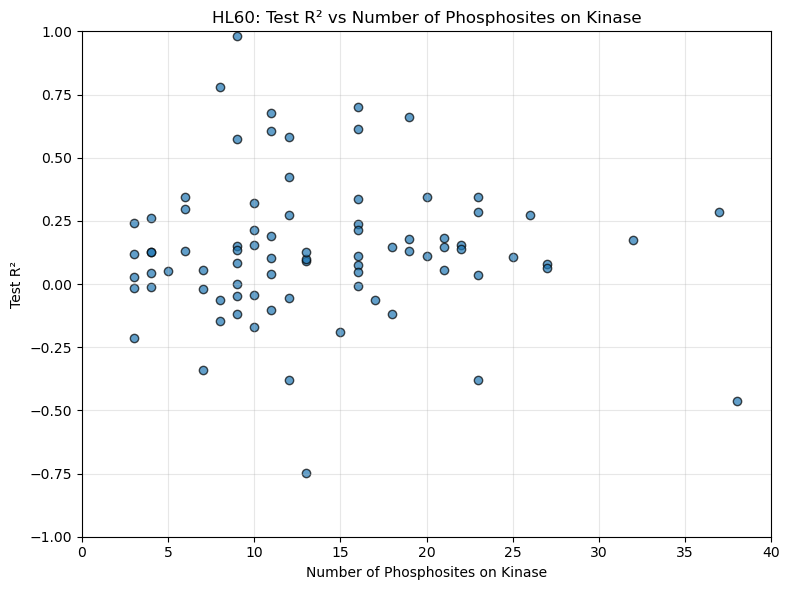

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    r2_phosphosite["TotalPhosphosites"],
    r2_phosphosite["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Number of Phosphosites on Kinase")
plt.ylabel("Test R²")
plt.title("HL60: Test R² vs Number of Phosphosites on Kinase")

# ---------- Fixed axes ----------
plt.xlim(0, 40)
plt.ylim(-1.0, 1.0)
# -------------------------------

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("HL60_R2_vs_Kinase_Phosphosite_Count.png", dpi=300)

plt.show()

In [71]:
print("Kinases:", len(merged_sites))

print("Total kinase phosphosites:",
      merged_sites["TotalPhosphosites"].sum())

print("Total target phosphosites:",
      merged_sites["TargetPhosphositeCount"].sum())

Kinases: 504
Total kinase phosphosites: 3337
Total target phosphosites: 32748
